# Projeto Integrador - Exploração e Tratamento Inicial

Este notebook serve como o primeiro passo para o projeto. Aqui vamos fazer a ingestão exploratória das 3 fontes (BCB, IBGE e SIM/SUS), além da limpeza básica dos dados (remoção de nulos, tipagem e deduplicação) e algumas visualizações iniciais.

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import io

# Configurações visuais do seaborn
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Banco Central (BCB) - Inadimplência
Vamos buscar a série histórica de inadimplência de operações de crédito (Série SGS 21082).

In [2]:
# --- INGESTÃO ---
url_bcb = 'https://api.bcb.gov.br/dados/serie/bcdata.sgs.21082/dados?formato=json&dataInicial=01/01/2019'
resp_bcb = requests.get(url_bcb)
df_bcb = pd.DataFrame(resp_bcb.json())

# --- TRATAMENTO (Limpeza e Tipagem) ---
df_bcb['data'] = pd.to_datetime(df_bcb['data'], format='%d/%m/%Y')
df_bcb['valor'] = pd.to_numeric(df_bcb['valor'], errors='coerce')

# Remoção de nulos e duplicatas
df_bcb = df_bcb.dropna(subset=['valor'])
df_bcb = df_bcb.drop_duplicates(subset=['data'])
df_bcb = df_bcb.sort_values('data')

print("Registros BCB:", len(df_bcb))
df_bcb.head()

Registros BCB: 91


,data,valor
0,2019-01-01,3.01
1,2019-02-01,2.96
2,2019-03-01,3.04
3,2019-04-01,3.07
4,2019-05-01,3.10


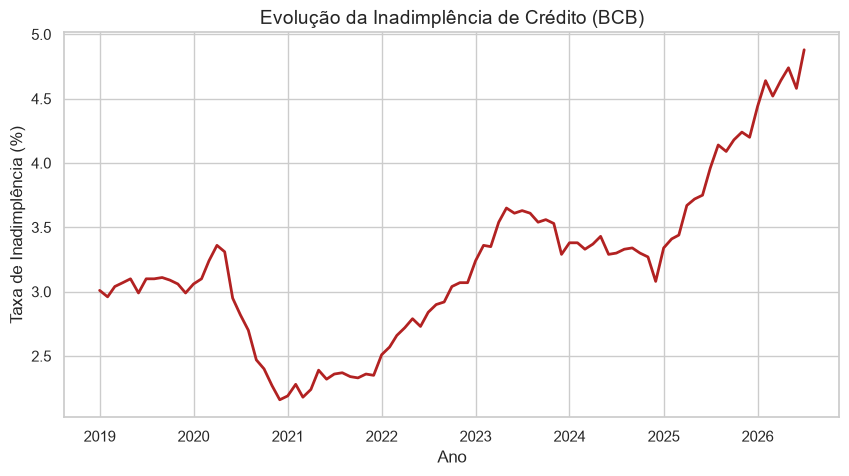

In [3]:
# --- PLOT BCB ---
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_bcb, x='data', y='valor', color='firebrick', linewidth=2)
plt.title('Evolução da Inadimplência de Crédito (BCB)', fontsize=14)
plt.ylabel('Taxa de Inadimplência (%)')
plt.xlabel('Ano')
plt.show()

## 2. IBGE - População dos Estados
Vamos puxar dados populacionais dos Estados via API de agregados do IBGE (SIDRA).

In [4]:
# --- INGESTÃO ---
# Tabela 4709 (População residente estimativa), Variável 9324
url_ibge = "https://servicodados.ibge.gov.br/api/v3/agregados/4709/periodos/2021/variaveis/9324?localidades=N3[all]"
resp_ibge = requests.get(url_ibge)
dados_ibge = resp_ibge.json()

# Parsing do JSON complexo do SIDRA
registros_pop = []
for resultado in dados_ibge[0]['resultados']:
    for serie in resultado['series']:
        registros_pop.append({
            'uf': serie['localidade']['nome'],
            'codigo_uf': serie['localidade']['id'],
            'populacao': serie['serie']['2021']
        })

df_pop = pd.DataFrame(registros_pop)

# --- TRATAMENTO ---
df_pop['populacao'] = pd.to_numeric(df_pop['populacao'], errors='coerce')
df_pop = df_pop.dropna(subset=['populacao'])

# Ordenar para plot
df_pop = df_pop.sort_values('populacao', ascending=False)

print("Registros IBGE:", len(df_pop))
df_pop.head()

KeyError: 0

In [5]:
# --- PLOT IBGE ---
plt.figure(figsize=(12, 6))
sns.barplot(data=df_pop.head(10), x='populacao', y='uf', palette='viridis')
plt.title('Top 10 Estados por População Estimada', fontsize=14)
plt.xlabel('População')
plt.ylabel('Estado')
plt.show()

NameError: name 'df_pop' is not defined

<Figure size 1200x600 with 0 Axes>

## 3. SIM / OpenDataSUS - Mortalidade
Baixando um arquivo CSV ZIP direto do DataSUS (exemplo de 2023). Esse processo pode demorar um pouco dependendo da internet, pois o arquivo tem ~40MB compactado.

In [6]:
# --- INGESTÃO ---
url_sim = 'https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/SIM/csv/DO23OPEN_csv.zip'
print("Baixando arquivo ZIP do SIM...")
resp_sim = requests.get(url_sim)
resp_sim.raise_for_status()

print("Extraindo e lendo CSV...")
with zipfile.ZipFile(io.BytesIO(resp_sim.content)) as z:
    csv_filename = [f for f in z.namelist() if f.endswith('.csv')][0]
    with z.open(csv_filename) as f:
        # Pegando as colunas mais importantes para o projeto
        colunas_uteis = ['DTOBITO', 'CODMUNRES', 'CAUSABAS']
        df_sim = pd.read_csv(f, sep=';', encoding='latin-1', usecols=colunas_uteis, dtype=str)

print("Total carregado:", len(df_sim))


Baixando arquivo ZIP do SIM...


HTTPError: 403 Client Error: Forbidden for url: https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/SIM/csv/DO23OPEN_csv.zip

In [7]:
# --- TRATAMENTO ---
# Converter data de óbito 
df_sim['DTOBITO'] = pd.to_datetime(df_sim['DTOBITO'], format='%d%m%Y', errors='coerce')

# Limpeza de nulos essenciais e registros corrompidos
df_sim = df_sim.dropna(subset=['DTOBITO', 'CAUSABAS', 'CODMUNRES'])

# Extrair o capítulo do CID10 (primeira letra da causa básica)
df_sim['CAPITULO_CID'] = df_sim['CAUSABAS'].str[0]

print("Total após limpeza de nulos:", len(df_sim))
df_sim.head()

NameError: name 'df_sim' is not defined

In [8]:
# --- PLOT SIM ---
# Frequencia das causas baseadas no capítulo do CID-10
causas_freq = df_sim['CAPITULO_CID'].value_counts().head(10).reset_index()
causas_freq.columns = ['Capítulo CID', 'Contagem']

plt.figure(figsize=(10, 6))
sns.barplot(data=causas_freq, x='Capítulo CID', y='Contagem', palette='magma')
plt.title('Top 10 Capítulos do CID-10 mais frequentes nos Óbitos (2023)', fontsize=14)
plt.ylabel('Número de Óbitos')
plt.xlabel('Letra Inicial do CID (Capítulo)')
plt.show()

print("Obs: 'I' = Doenças do Aparelho Circulatório, 'C' = Cânceres, 'J' = Respiratórias")

NameError: name 'df_sim' is not defined